# Q1 Low-Field Region Diagnostics

This notebook probes the exact compact reduced model for `transitions.Q1_F1_1o2_F0` on a dense low-field grid. The goal is to see whether the bad behavior near about `8 V/cm` is already present in the exact compact model through a sharp spectral, subspace, or decay-structure change.


In [1]:
from importlib.machinery import SourceFileLoader
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid

from centrex_tlf import couplings, states, transitions

runtime_relpath = Path(
    "examples/effective hamiltonian/effective_hamiltonian_runtime.py"
)
repo_root = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / runtime_relpath).exists()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError(runtime_relpath)

ehr = SourceFileLoader("ehr", str(repo_root / runtime_relpath)).load_module()


In [2]:
TRANSITION = transitions.Q1_F1_1o2_F0
OPTICAL_POLARIZATION = couplings.polarization_Z
B_FIELD = (0.0, 0.0, 1e-5)

COARSE_STEP_VCM = 0.25
FINE_WINDOW_VCM = (7.0, 9.0)
FINE_STEP_VCM = 0.01

COARSE_FIELDS_VCM = np.arange(0.0, 15.0 + 0.5 * COARSE_STEP_VCM, COARSE_STEP_VCM)
FINE_FIELDS_VCM = np.arange(
    FINE_WINDOW_VCM[0],
    FINE_WINDOW_VCM[1] + 0.5 * FINE_STEP_VCM,
    FINE_STEP_VCM,
)
FIELD_GRID_VCM = np.unique(
    np.round(np.concatenate([COARSE_FIELDS_VCM, FINE_FIELDS_VCM]), 8)
)

SPOT_FIELDS_VCM = np.array([5.0, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0])

RABI_RATE = 2.0 * np.pi * 1e6
DETUNING = 0.0
T_FINAL = 10e-6
N_T = 500
T_EVAL = np.linspace(0.0, T_FINAL, N_T)


In [3]:
def rate_to_mhz(value):
    return float(np.real(value) / (2.0 * np.pi * 1e6))


def build_compact_bundle(field_vcm: float):
    return ehr.build_compact_reference_decomposed_bundle(
        transition=TRANSITION,
        optical_polarization=OPTICAL_POLARIZATION,
        electric_field=(0.0, 0.0, float(field_vcm)),
        magnetic_field=B_FIELD,
    )


def selector_indices(qn, selector):
    return np.asarray(selector.get_indices(qn), dtype=np.int64)


def active_lower_indices(system):
    selector = states.QuantumSelector(
        J=int(TRANSITION.J_ground),
        electronic=TRANSITION.electronic_ground,
    )
    return selector_indices(system.QN, selector)


def excited_indices(system):
    selector = states.QuantumSelector(electronic=TRANSITION.electronic_excited)
    return selector_indices(system.QN, selector)


def all_lower_indices(system):
    selector = states.QuantumSelector(electronic=TRANSITION.electronic_ground)
    return selector_indices(system.QN, selector)


def sink_indices(system):
    lower = all_lower_indices(system)
    active = active_lower_indices(system)
    return np.asarray(
        sorted(set(lower.tolist()) - set(active.tolist())), dtype=np.int64
    )


def sink_indices_by_j(system):
    lower_states = [system.QN[idx] for idx in all_lower_indices(system)]
    available_js = sorted({int(round(qn.largest.J)) for qn in lower_states})
    groups = {}
    for J in available_js:
        if J == int(TRANSITION.J_ground):
            continue
        selector = states.QuantumSelector(J=J, electronic=TRANSITION.electronic_ground)
        idx = selector_indices(system.QN, selector)
        if idx.size:
            groups[J] = idx
    return groups


def state_sector_weights(qn):
    weights = {
        "x_j0": 0.0,
        "x_j1": 0.0,
        "x_j2": 0.0,
        "x_other": 0.0,
        "b": 0.0,
        "other": 0.0,
    }
    for amp, basis_state in qn.data:
        prob = float(np.abs(amp) ** 2)
        elec = basis_state.electronic_state
        J = None if basis_state.J is None else int(round(basis_state.J))
        if elec == states.ElectronicState.X:
            if J == 0:
                weights["x_j0"] += prob
            elif J == 1:
                weights["x_j1"] += prob
            elif J == 2:
                weights["x_j2"] += prob
            else:
                weights["x_other"] += prob
        elif elec == states.ElectronicState.B:
            weights["b"] += prob
        else:
            weights["other"] += prob
    weights["total"] = sum(weights.values())
    return weights


def coherent_subspace_singular_values(system_a, system_b):
    idx_a = active_lower_indices(system_a)
    idx_b = active_lower_indices(system_b)
    overlap = np.zeros((idx_a.size, idx_b.size), dtype=np.complex128)
    for row, ia in enumerate(idx_a):
        for col, ib in enumerate(idx_b):
            overlap[row, col] = system_a.QN[ia] @ system_b.QN[ib]
    return np.linalg.svd(overlap, compute_uv=False)


def decay_breakdown(system, bundle):
    active = active_lower_indices(system)
    excited = np.asarray(bundle.excited_indices, dtype=np.int64)
    active_kernel = ehr._sector_decay_kernel(bundle.c_array, excited, active)
    active_rate = float(np.sum(np.real(np.diag(active_kernel))))
    sink_rates = {}
    for J, indices in sink_indices_by_j(system).items():
        kernel = ehr._sector_decay_kernel(bundle.c_array, excited, indices)
        sink_rates[J] = float(np.sum(np.real(np.diag(kernel))))
    total_rate = active_rate + sum(sink_rates.values())
    return {
        "total_rate_rad_s": total_rate,
        "active_rate_rad_s": active_rate,
        "sink_rates_rad_s": sink_rates,
        "active_branch": np.nan if total_rate == 0.0 else active_rate / total_rate,
        **{
            f"sink_branch_J{J}": np.nan if total_rate == 0.0 else rate / total_rate
            for J, rate in sink_rates.items()
        },
    }


def brightest_active_ground_index(bundle, active_indices):
    if active_indices.size == 0:
        raise ValueError("No active lower states found.")
    h_opt = np.asarray(bundle.h_opt)
    excited = np.asarray(bundle.excited_indices, dtype=np.int64)
    scores = [float(np.linalg.norm(h_opt[idx, excited])) for idx in active_indices]
    return int(active_indices[int(np.argmax(scores))])


def photon_rate(solution, bundle):
    jump_rate = np.asarray(bundle.jump_rate_operator())
    dim = bundle.h_internal.shape[0]
    rates = []
    for column in solution.y.T:
        rho = column.reshape(dim, dim)
        rates.append(float(np.real(np.trace(rho @ jump_rate))))
    return np.asarray(rates, dtype=np.float64)


def integrated_photons(rate, t_eval):
    return float(np.trapezoid(rate, x=t_eval))


def compact_summary_row(field_vcm, system, bundle):
    h_internal = np.asarray(bundle.h_internal)
    eigenvalues = np.sort(np.real(np.linalg.eigvalsh(h_internal)))
    min_gap = np.nan
    if eigenvalues.size >= 2:
        min_gap = float(np.min(np.diff(eigenvalues)))
    active = active_lower_indices(system)
    sink = sink_indices(system)
    decay = decay_breakdown(system, bundle)

    active_weights = [state_sector_weights(system.QN[idx]) for idx in active]
    excited_weights = [
        state_sector_weights(system.QN[idx]) for idx in bundle.excited_indices
    ]

    row = {
        "field_vcm": float(field_vcm),
        "dimension": int(h_internal.shape[0]),
        "n_active_lower": int(active.size),
        "n_sink": int(sink.size),
        "n_excited": int(np.asarray(bundle.excited_indices).size),
        "min_gap_mhz": np.nan if np.isnan(min_gap) else rate_to_mhz(min_gap),
        "total_decay_mhz": rate_to_mhz(decay["total_rate_rad_s"]),
        "active_decay_mhz": rate_to_mhz(decay["active_rate_rad_s"]),
        "active_branch": decay["active_branch"],
        "active_min_xj1_weight": np.nan
        if not active_weights
        else min(w["x_j1"] for w in active_weights),
        "active_max_xj0_weight": np.nan
        if not active_weights
        else max(w["x_j0"] for w in active_weights),
        "active_max_xj2_weight": np.nan
        if not active_weights
        else max(w["x_j2"] for w in active_weights),
        "excited_min_b_weight": np.nan
        if not excited_weights
        else min(w["b"] for w in excited_weights),
        "excited_max_xj0_weight": np.nan
        if not excited_weights
        else max(w["x_j0"] for w in excited_weights),
        "excited_max_xj2_weight": np.nan
        if not excited_weights
        else max(w["x_j2"] for w in excited_weights),
    }
    for J, rate in decay["sink_rates_rad_s"].items():
        row[f"sink_decay_J{J}_mhz"] = rate_to_mhz(rate)
        row[f"sink_branch_J{J}"] = decay[f"sink_branch_J{J}"]
    return row


In [4]:
systems_by_field = {}
bundles_by_field = {}
summary_rows = []
state_rows = []

for field_vcm in FIELD_GRID_VCM:
    system, bundle = build_compact_bundle(float(field_vcm))
    systems_by_field[float(field_vcm)] = system
    bundles_by_field[float(field_vcm)] = bundle
    summary_rows.append(compact_summary_row(field_vcm, system, bundle))

    energies = np.real(np.diag(np.asarray(bundle.h_internal))) / (2.0 * np.pi * 1e6)
    active = set(active_lower_indices(system).tolist())
    sinks = set(sink_indices(system).tolist())
    excited = set(np.asarray(bundle.excited_indices, dtype=np.int64).tolist())

    for idx, qn in enumerate(system.QN):
        weights = state_sector_weights(qn)
        role = "other"
        if idx in active:
            role = "active_lower"
        elif idx in sinks:
            role = "sink"
        elif idx in excited:
            role = "excited"
        state_rows.append(
            {
                "field_vcm": float(field_vcm),
                "state_index": int(idx),
                "role": role,
                "energy_mhz": float(energies[idx]),
                **weights,
            }
        )

summary_df = pd.DataFrame(summary_rows).sort_values("field_vcm", kind="mergesort")
state_df = pd.DataFrame(state_rows).sort_values(
    ["field_vcm", "state_index"], kind="mergesort"
)
summary_df.head()


,field_vcm,dimension,n_active_lower,n_sink,n_excited,min_gap_mhz,total_decay_mhz,active_decay_mhz,active_branch,active_min_xj1_weight,active_max_xj0_weight,active_max_xj2_weight,excited_min_b_weight,excited_max_xj0_weight,excited_max_xj2_weight,sink_decay_J0_mhz,sink_branch_J0,sink_decay_J2_mhz,sink_branch_J2
0,0.00,13,12,0,1,0.0,1.56,1.56,1.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
1,0.25,13,12,0,1,0.0,1.56,1.56,1.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
2,0.50,13,12,0,1,0.0,1.56,1.56,1.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
3,0.75,13,12,0,1,0.0,1.56,1.56,1.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
4,1.00,13,12,0,1,0.0,1.56,1.56,1.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN


## Reduced-model structure over the low-field scan


In [5]:
structure_cols = [
    "field_vcm",
    "dimension",
    "n_active_lower",
    "n_sink",
    "n_excited",
    "min_gap_mhz",
    "total_decay_mhz",
    "active_branch",
]
summary_df.loc[:, structure_cols]


,field_vcm,dimension,n_active_lower,n_sink,n_excited,min_gap_mhz,total_decay_mhz,active_branch
0,0.00,13,12,0,1,0.0,1.56,1.000000
1,0.25,13,12,0,1,0.0,1.56,1.000000
2,0.50,13,12,0,1,0.0,1.56,1.000000
3,0.75,13,12,0,1,0.0,1.56,1.000000
4,1.00,13,12,0,1,0.0,1.56,1.000000
...,...,...,...,...,...,...,...,...
248,14.00,15,12,2,1,0.0,1.56,0.999905
249,14.25,15,12,2,1,0.0,1.56,0.999902
250,14.50,15,12,2,1,0.0,1.56,0.999899
251,14.75,15,12,2,1,0.0,1.56,0.999895


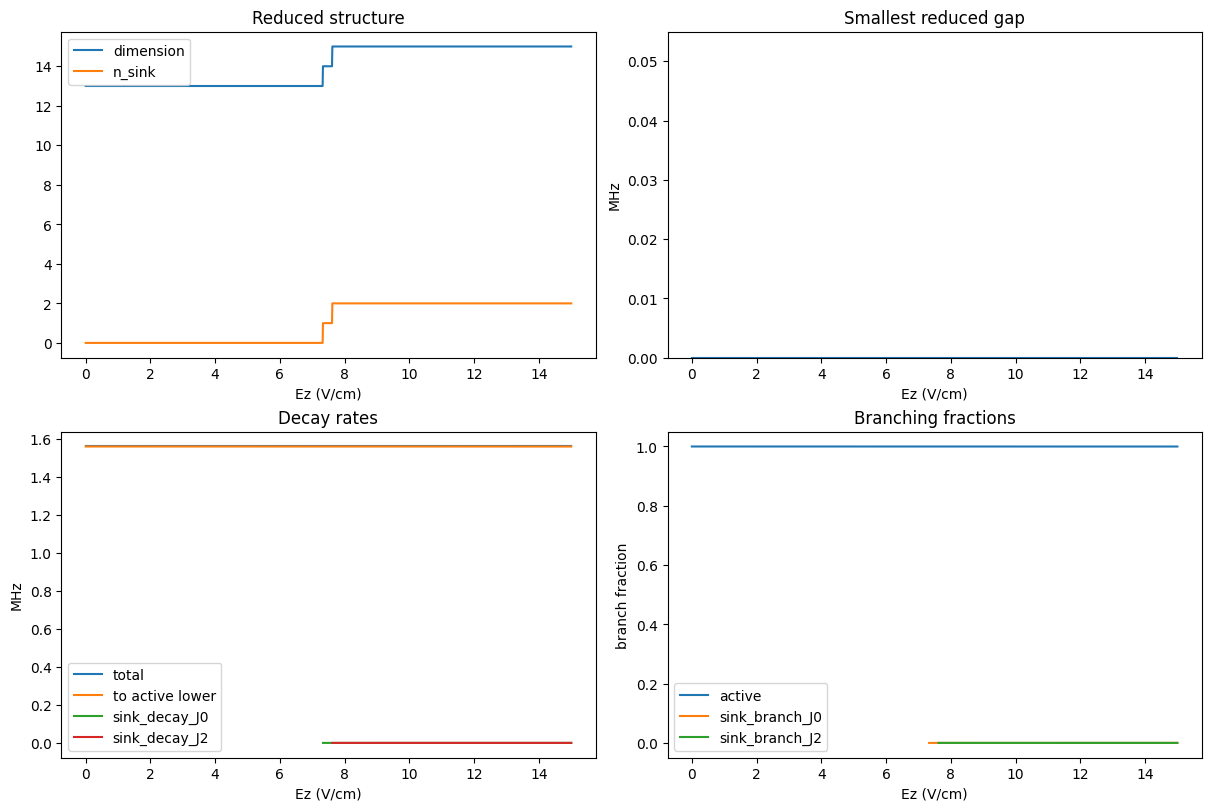

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].plot(summary_df.field_vcm, summary_df.dimension, label="dimension")
axes[0, 0].plot(summary_df.field_vcm, summary_df.n_sink, label="n_sink")
axes[0, 0].set_xlabel("Ez (V/cm)")
axes[0, 0].set_title("Reduced structure")
axes[0, 0].legend()

axes[0, 1].plot(summary_df.field_vcm, summary_df.min_gap_mhz)
axes[0, 1].set_xlabel("Ez (V/cm)")
axes[0, 1].set_ylabel("MHz")
axes[0, 1].set_title("Smallest reduced gap")
axes[0, 1].set_ylim(bottom=0.0)

axes[1, 0].plot(summary_df.field_vcm, summary_df.total_decay_mhz, label="total")
axes[1, 0].plot(
    summary_df.field_vcm, summary_df.active_decay_mhz, label="to active lower"
)
for col in [c for c in summary_df.columns if c.startswith("sink_decay_J")]:
    axes[1, 0].plot(
        summary_df.field_vcm, summary_df[col], label=col.replace("_mhz", "")
    )
axes[1, 0].set_xlabel("Ez (V/cm)")
axes[1, 0].set_ylabel("MHz")
axes[1, 0].set_title("Decay rates")
axes[1, 0].legend()

axes[1, 1].plot(summary_df.field_vcm, summary_df.active_branch, label="active")
for col in [c for c in summary_df.columns if c.startswith("sink_branch_J")]:
    axes[1, 1].plot(summary_df.field_vcm, summary_df[col], label=col)
axes[1, 1].set_xlabel("Ez (V/cm)")
axes[1, 1].set_ylabel("branch fraction")
axes[1, 1].set_title("Branching fractions")
axes[1, 1].legend()

plt.show()


## Exact compact reduced spectrum


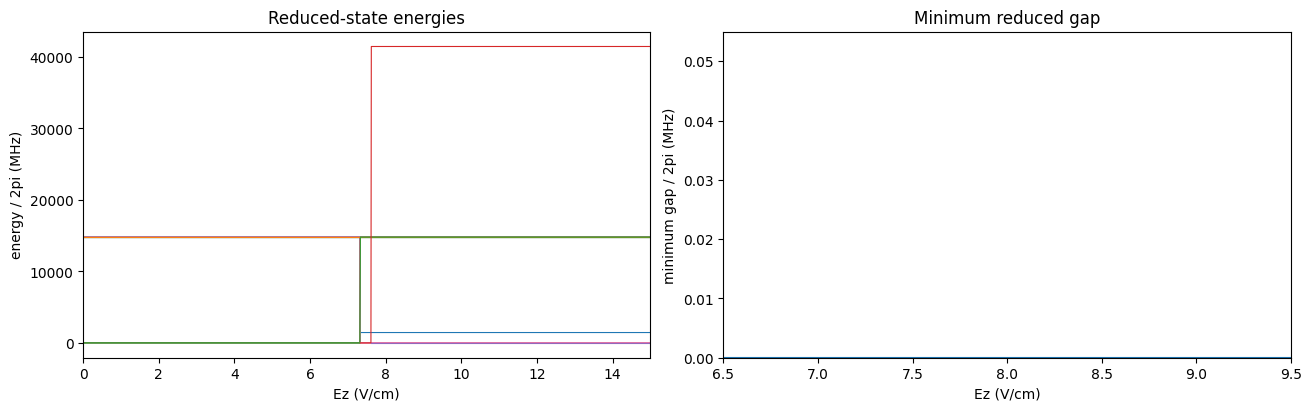

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

for state_index, group in state_df.groupby("state_index"):
    axes[0].plot(group.field_vcm, group.energy_mhz, lw=0.8)
axes[0].set_xlabel("Ez (V/cm)")
axes[0].set_ylabel("energy / 2pi (MHz)")
axes[0].set_title("Reduced-state energies")
axes[0].set_xlim(0.0, 15.0)

axes[1].plot(summary_df.field_vcm, summary_df.min_gap_mhz)
axes[1].set_xlabel("Ez (V/cm)")
axes[1].set_ylabel("minimum gap / 2pi (MHz)")
axes[1].set_title("Minimum reduced gap")
axes[1].set_xlim(6.5, 9.5)
axes[1].set_ylim(bottom=0.0)

plt.show()


## State character in the exact compact basis


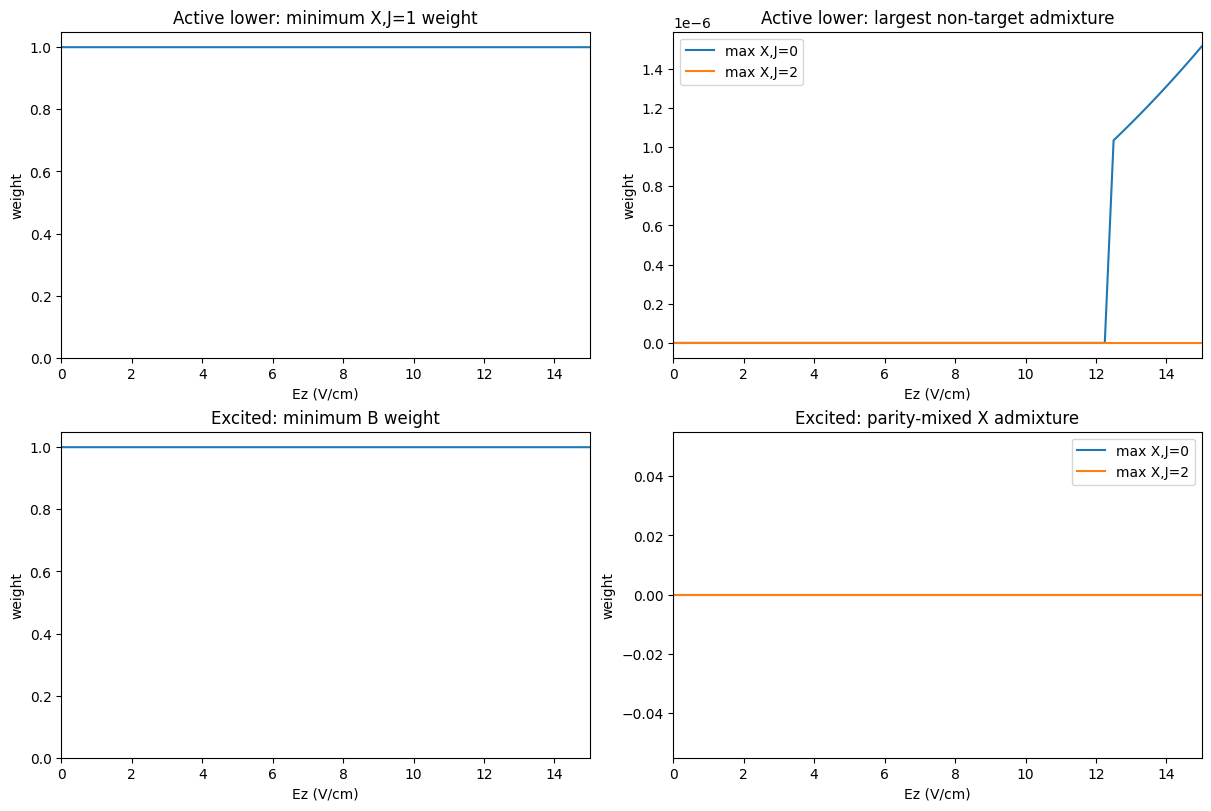

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].plot(summary_df.field_vcm, summary_df.active_min_xj1_weight)
axes[0, 0].set_title("Active lower: minimum X,J=1 weight")
axes[0, 0].set_xlabel("Ez (V/cm)")
axes[0, 0].set_ylabel("weight")
axes[0, 0].set_ylim(0.0, 1.05)

axes[0, 1].plot(
    summary_df.field_vcm, summary_df.active_max_xj0_weight, label="max X,J=0"
)
axes[0, 1].plot(
    summary_df.field_vcm, summary_df.active_max_xj2_weight, label="max X,J=2"
)
axes[0, 1].set_title("Active lower: largest non-target admixture")
axes[0, 1].set_xlabel("Ez (V/cm)")
axes[0, 1].set_ylabel("weight")
axes[0, 1].legend()

axes[1, 0].plot(summary_df.field_vcm, summary_df.excited_min_b_weight)
axes[1, 0].set_title("Excited: minimum B weight")
axes[1, 0].set_xlabel("Ez (V/cm)")
axes[1, 0].set_ylabel("weight")
axes[1, 0].set_ylim(0.0, 1.05)

axes[1, 1].plot(
    summary_df.field_vcm, summary_df.excited_max_xj0_weight, label="max X,J=0"
)
axes[1, 1].plot(
    summary_df.field_vcm, summary_df.excited_max_xj2_weight, label="max X,J=2"
)
axes[1, 1].set_title("Excited: parity-mixed X admixture")
axes[1, 1].set_xlabel("Ez (V/cm)")
axes[1, 1].set_ylabel("weight")
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlim(0.0, 15.0)

plt.show()


In [9]:
character_zoom = summary_df.loc[
    (summary_df.field_vcm >= 6.5) & (summary_df.field_vcm <= 9.5)
]
character_zoom.loc[
    :,
    [
        "field_vcm",
        "active_min_xj1_weight",
        "active_max_xj0_weight",
        "active_max_xj2_weight",
        "excited_min_b_weight",
        "excited_max_xj0_weight",
        "excited_max_xj2_weight",
    ],
].head(25)


,field_vcm,active_min_xj1_weight,active_max_xj0_weight,active_max_xj2_weight,excited_min_b_weight,excited_max_xj0_weight,excited_max_xj2_weight
26,6.50,1.0,0.0,0.0,1.0,0.0,0.0
27,6.75,1.0,0.0,0.0,1.0,0.0,0.0
28,7.00,1.0,0.0,0.0,1.0,0.0,0.0
29,7.01,1.0,0.0,0.0,1.0,0.0,0.0
30,7.02,1.0,0.0,0.0,1.0,0.0,0.0
31,7.03,1.0,0.0,0.0,1.0,0.0,0.0
32,7.04,1.0,0.0,0.0,1.0,0.0,0.0
33,7.05,1.0,0.0,0.0,1.0,0.0,0.0
34,7.06,1.0,0.0,0.0,1.0,0.0,0.0
35,7.07,1.0,0.0,0.0,1.0,0.0,0.0


## Neighboring coherent-subspace overlaps


In [10]:
overlap_rows = []
for field_left, field_right in zip(FIELD_GRID_VCM[:-1], FIELD_GRID_VCM[1:]):
    singular_values = coherent_subspace_singular_values(
        systems_by_field[float(field_left)],
        systems_by_field[float(field_right)],
    )
    overlap_rows.append(
        {
            "field_left_vcm": float(field_left),
            "field_right_vcm": float(field_right),
            "field_mid_vcm": 0.5 * float(field_left + field_right),
            "min_singular_value": float(np.min(singular_values)),
            "max_singular_value": float(np.max(singular_values)),
        }
    )

overlap_df = pd.DataFrame(overlap_rows)
overlap_df.nsmallest(20, "min_singular_value")


,field_left_vcm,field_right_vcm,field_mid_vcm,min_singular_value,max_singular_value
130,8.02,8.03,8.025,0.999613,1.000386
191,8.63,8.64,8.635,0.999700,1.000299
129,8.01,8.02,8.015,0.999717,1.000282
246,13.50,13.75,13.625,0.999726,1.000272
247,13.75,14.00,13.875,0.999726,1.000272
118,7.90,7.91,7.905,0.999735,1.000264
197,8.69,8.70,8.695,0.999755,1.000244
91,7.63,7.64,7.635,0.999764,1.000235
208,8.80,8.81,8.805,0.999771,1.000228
173,8.45,8.46,8.455,0.999802,1.000197


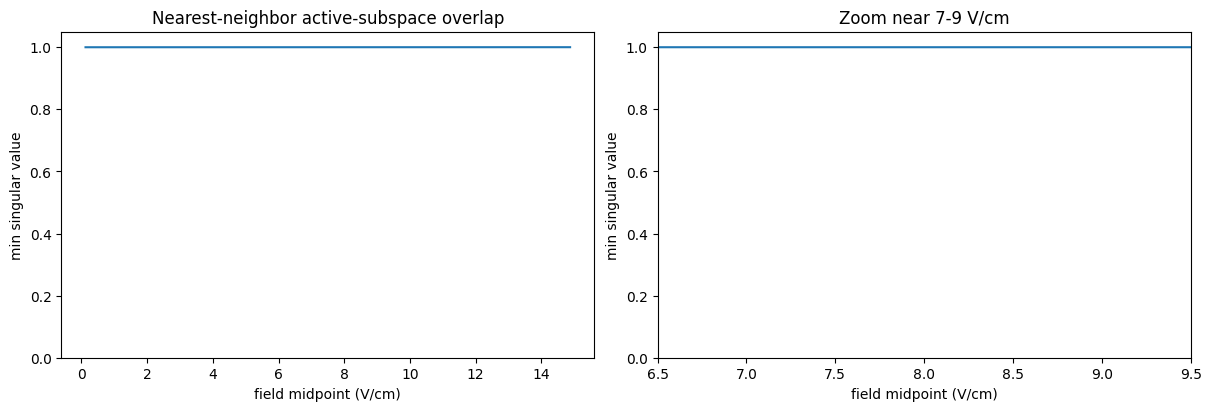

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(overlap_df.field_mid_vcm, overlap_df.min_singular_value)
axes[0].set_xlabel("field midpoint (V/cm)")
axes[0].set_ylabel("min singular value")
axes[0].set_title("Nearest-neighbor active-subspace overlap")
axes[0].set_ylim(0.0, 1.05)

axes[1].plot(overlap_df.field_mid_vcm, overlap_df.min_singular_value)
axes[1].set_xlabel("field midpoint (V/cm)")
axes[1].set_ylabel("min singular value")
axes[1].set_title("Zoom near 7-9 V/cm")
axes[1].set_xlim(6.5, 9.5)
axes[1].set_ylim(0.0, 1.05)

plt.show()


## Static scattering spot checks near the suspicious region


In [12]:
spot_results = []
spot_rates = {}
spot_cumulative = {}

for field_vcm in SPOT_FIELDS_VCM:
    system = systems_by_field[float(field_vcm)]
    bundle = bundles_by_field[float(field_vcm)]
    active = active_lower_indices(system)
    bright_idx = brightest_active_ground_index(bundle, active)
    rho0 = np.zeros(
        (bundle.h_internal.shape[0], bundle.h_internal.shape[0]), dtype=np.complex128
    )
    rho0[bright_idx, bright_idx] = 1.0

    solution = ehr.solve_static_density_matrix_bundle(
        bundle,
        rho0=rho0,
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
        method="RK45",
    )
    rate = photon_rate(solution, bundle)
    cumulative = cumulative_trapezoid(rate, T_EVAL, initial=0.0)
    spot_rates[float(field_vcm)] = rate
    spot_cumulative[float(field_vcm)] = cumulative
    spot_results.append(
        {
            "field_vcm": float(field_vcm),
            "integrated_photons": integrated_photons(rate, T_EVAL),
            "final_rate_hz": float(rate[-1]),
            "peak_rate_hz": float(np.max(rate)),
        }
    )

spot_df = pd.DataFrame(spot_results).sort_values("field_vcm", kind="mergesort")
spot_df


,field_vcm,integrated_photons,final_rate_hz,peak_rate_hz
0,5.0,1.154118,16547.532599,2.764186e+06
1,7.0,1.154118,16547.532598,2.764186e+06
2,7.5,1.160625,15626.511339,2.882144e+06
3,8.0,1.160838,15399.189517,2.885001e+06
4,8.5,1.161639,15422.504127,2.900246e+06
5,9.0,1.162658,15278.259963,2.916332e+06
6,10.0,1.164756,14891.246740,2.950958e+06


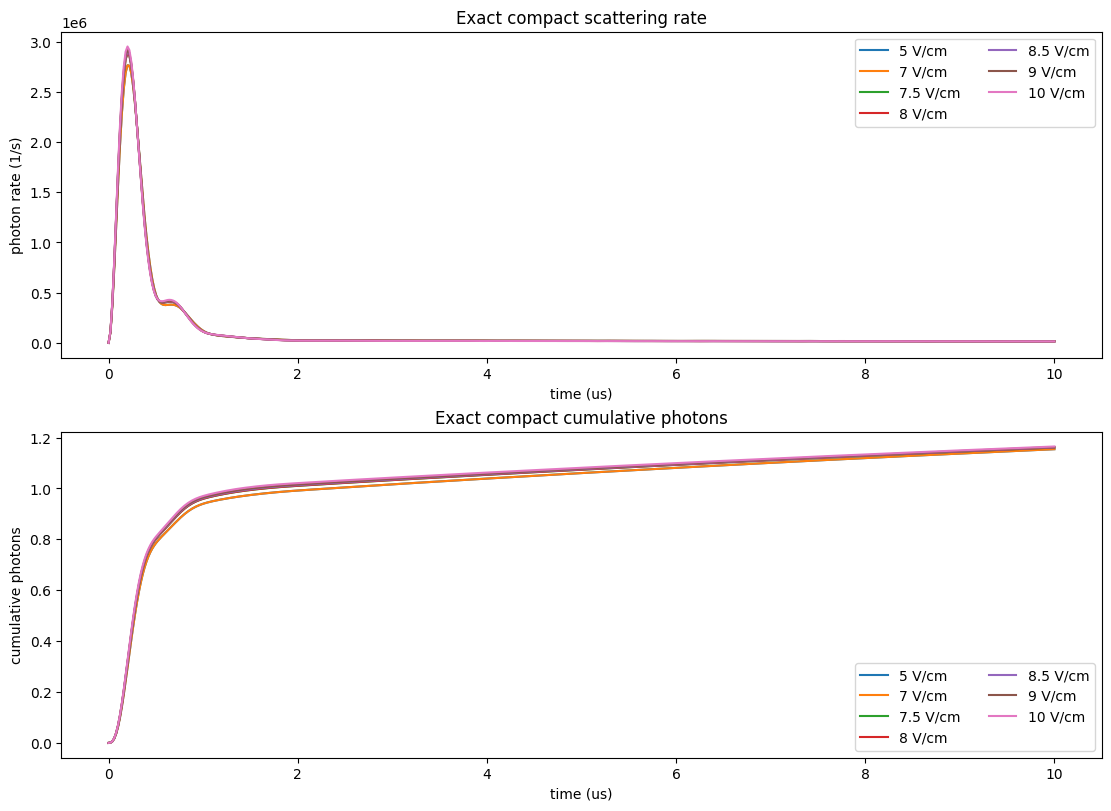

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

for field_vcm in SPOT_FIELDS_VCM:
    axes[0].plot(
        1e6 * T_EVAL, spot_rates[float(field_vcm)], label=f"{field_vcm:g} V/cm"
    )
axes[0].set_xlabel("time (us)")
axes[0].set_ylabel("photon rate (1/s)")
axes[0].set_title("Exact compact scattering rate")
axes[0].legend(ncol=2)

for field_vcm in SPOT_FIELDS_VCM:
    axes[1].plot(
        1e6 * T_EVAL, spot_cumulative[float(field_vcm)], label=f"{field_vcm:g} V/cm"
    )
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("cumulative photons")
axes[1].set_title("Exact compact cumulative photons")
axes[1].legend(ncol=2)

plt.show()


## Focused tables near the low-field trouble region


In [14]:
summary_df.loc[
    (summary_df.field_vcm >= 7.0) & (summary_df.field_vcm <= 9.0),
    [
        "field_vcm",
        "dimension",
        "n_sink",
        "min_gap_mhz",
        "active_branch",
        "sink_branch_J0",
        "sink_branch_J2",
        "active_min_xj1_weight",
        "active_max_xj0_weight",
        "active_max_xj2_weight",
        "excited_min_b_weight",
        "excited_max_xj0_weight",
        "excited_max_xj2_weight",
    ],
].head(60)


,field_vcm,dimension,n_sink,min_gap_mhz,active_branch,sink_branch_J0,sink_branch_J2,active_min_xj1_weight,active_max_xj0_weight,active_max_xj2_weight,excited_min_b_weight,excited_max_xj0_weight,excited_max_xj2_weight
28,7.00,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
29,7.01,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
30,7.02,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
31,7.03,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
32,7.04,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
33,7.05,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
34,7.06,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
35,7.07,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
36,7.08,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0
37,7.09,13,0,0.0,1.000000,NaN,NaN,1.0,0.0,0.0,1.0,0.0,0.0


## Exact compact model embedded into a fixed union-sink layout

This section keeps the exact compact model, but embeds it into a fixed low-field union basis that already contains the sink slots across the whole interval. If the weird behavior is only caused by the compact dimension changing at about `7.33 V/cm`, this comparison should show it.


In [15]:
UNION_PATCH_FIELDS_VCM = [0.0, 7.5, 8.0, 10.0, 15.0]
union_layout_model = ehr.prepare_interpolated_effective_model(
    field_points=UNION_PATCH_FIELDS_VCM,
    transition=TRANSITION,
    optical_polarization=OPTICAL_POLARIZATION,
    magnetic_field=B_FIELD,
    master_field=0.0,
)
(
    union_layout_model.n_effective_states,
    union_layout_model.ground_indices.tolist(),
    union_layout_model.sink_indices.tolist(),
    union_layout_model.excited_indices.tolist(),
)


(15, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [12, 13], [14])

In [16]:
union_spot_results = []
union_spot_rates = {}
union_spot_cumulative = {}

for field_vcm in SPOT_FIELDS_VCM:
    _, union_bundle = ehr._aligned_exact_compact_bundle_for_field(
        union_layout_model,
        electric_field=(0.0, 0.0, float(field_vcm)),
    )
    bright_idx = int(union_layout_model.ground_main_index_p)
    rho0_union = np.zeros(
        (union_bundle.h_internal.shape[0], union_bundle.h_internal.shape[0]),
        dtype=np.complex128,
    )
    rho0_union[bright_idx, bright_idx] = 1.0

    union_solution = ehr.solve_static_density_matrix_bundle(
        union_bundle,
        rho0=rho0_union,
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
        method="RK45",
    )
    union_rate = photon_rate(union_solution, union_bundle)
    union_cumulative = cumulative_trapezoid(union_rate, T_EVAL, initial=0.0)
    union_spot_rates[float(field_vcm)] = union_rate
    union_spot_cumulative[float(field_vcm)] = union_cumulative
    union_spot_results.append(
        {
            "field_vcm": float(field_vcm),
            "integrated_photons_union_layout": integrated_photons(union_rate, T_EVAL),
            "final_rate_hz_union_layout": float(union_rate[-1]),
            "peak_rate_hz_union_layout": float(np.max(union_rate)),
        }
    )

union_spot_df = pd.DataFrame(union_spot_results).sort_values(
    "field_vcm", kind="mergesort"
)
comparison_df = spot_df.merge(union_spot_df, on="field_vcm", how="inner")
comparison_df["delta_integrated_photons"] = (
    comparison_df["integrated_photons_union_layout"]
    - comparison_df["integrated_photons"]
)
comparison_df["rel_integrated_photons"] = (
    comparison_df["delta_integrated_photons"] / comparison_df["integrated_photons"]
)
comparison_df


,field_vcm,integrated_photons,final_rate_hz,peak_rate_hz,integrated_photons_union_layout,final_rate_hz_union_layout,peak_rate_hz_union_layout,delta_integrated_photons,rel_integrated_photons
0,5.0,1.154118,16547.532599,2.764186e+06,1.153931,9818.976894,2.765726e+06,-0.000186,-0.000161
1,7.0,1.154118,16547.532598,2.764186e+06,1.153923,12441.050369,2.765726e+06,-0.000194,-0.000168
2,7.5,1.160625,15626.511339,2.882144e+06,1.151153,17111.990497,2.834062e+06,-0.009472,-0.008161
3,8.0,1.160838,15399.189517,2.885001e+06,1.149754,16022.662555,2.835660e+06,-0.011084,-0.009549
4,8.5,1.161639,15422.504127,2.900246e+06,1.149238,15585.359326,2.844414e+06,-0.012400,-0.010675
5,9.0,1.162658,15278.259963,2.916332e+06,1.148698,15622.187904,2.853628e+06,-0.013960,-0.012007
6,10.0,1.164756,14891.246740,2.950958e+06,1.147549,16707.687323,2.873372e+06,-0.017207,-0.014773


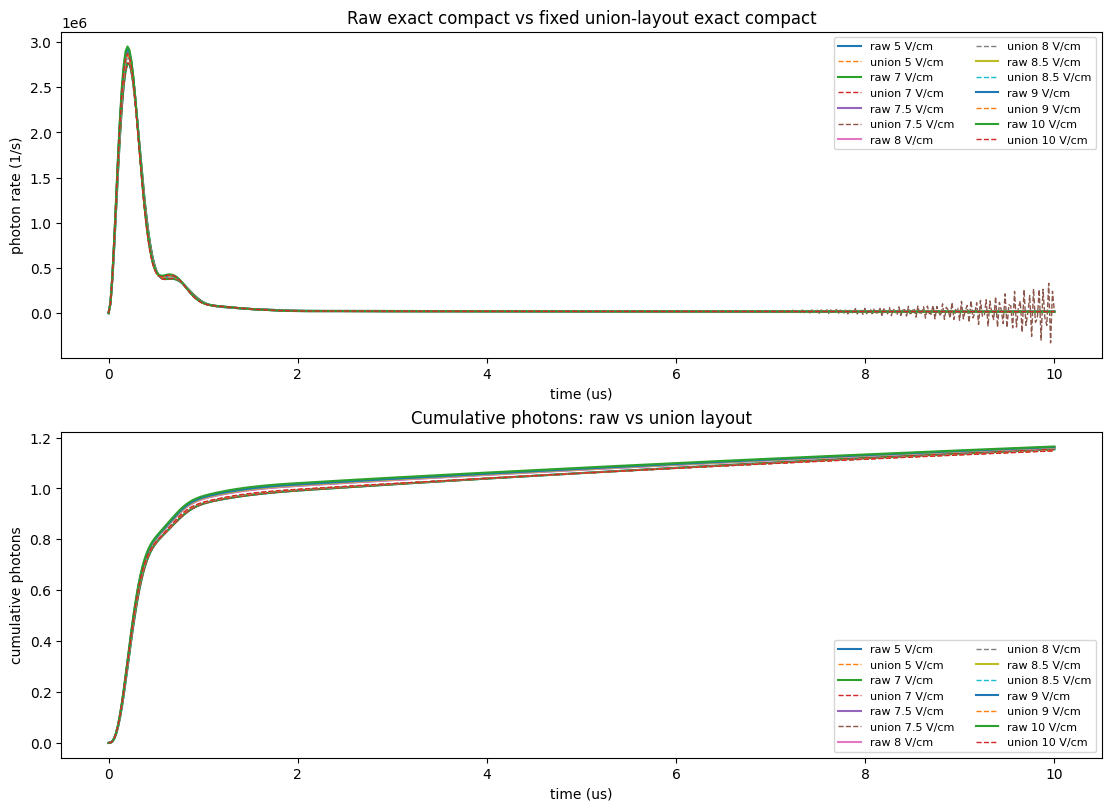

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

for field_vcm in SPOT_FIELDS_VCM:
    axes[0].plot(
        1e6 * T_EVAL,
        spot_rates[float(field_vcm)],
        lw=1.5,
        label=f"raw {field_vcm:g} V/cm",
    )
    axes[0].plot(
        1e6 * T_EVAL,
        union_spot_rates[float(field_vcm)],
        ls="--",
        lw=1.0,
        label=f"union {field_vcm:g} V/cm",
    )
axes[0].set_xlabel("time (us)")
axes[0].set_ylabel("photon rate (1/s)")
axes[0].set_title("Raw exact compact vs fixed union-layout exact compact")
axes[0].legend(ncol=2, fontsize=8)

for field_vcm in SPOT_FIELDS_VCM:
    axes[1].plot(
        1e6 * T_EVAL,
        spot_cumulative[float(field_vcm)],
        lw=1.5,
        label=f"raw {field_vcm:g} V/cm",
    )
    axes[1].plot(
        1e6 * T_EVAL,
        union_spot_cumulative[float(field_vcm)],
        ls="--",
        lw=1.0,
        label=f"union {field_vcm:g} V/cm",
    )
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("cumulative photons")
axes[1].set_title("Cumulative photons: raw vs union layout")
axes[1].legend(ncol=2, fontsize=8)

plt.show()


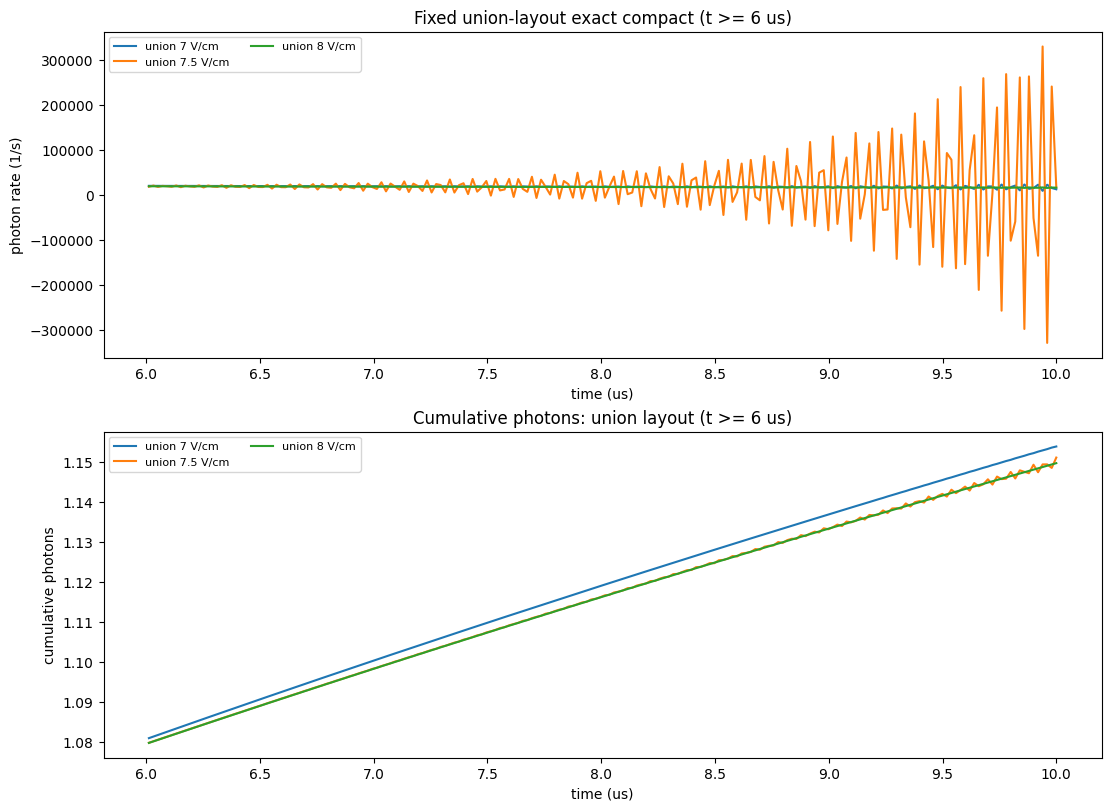

In [21]:
mask = T_EVAL >= 6e-6

fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

for field_vcm in SPOT_FIELDS_VCM:
    axes[0].plot(
        1e6 * T_EVAL[mask],
        union_spot_rates[float(field_vcm)][mask],
        lw=1.5,
        label=f"union {field_vcm:g} V/cm",
    )
axes[0].set_xlabel("time (us)")
axes[0].set_ylabel("photon rate (1/s)")
axes[0].set_title("Fixed union-layout exact compact (t >= 6 us)")
axes[0].legend(ncol=2, fontsize=8)

for field_vcm in SPOT_FIELDS_VCM:
    axes[1].plot(
        1e6 * T_EVAL[mask],
        union_spot_cumulative[float(field_vcm)][mask],
        lw=1.5,
        label=f"union {field_vcm:g} V/cm",
    )
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("cumulative photons")
axes[1].set_title("Cumulative photons: union layout (t >= 6 us)")
axes[1].legend(ncol=2, fontsize=8)

plt.show()


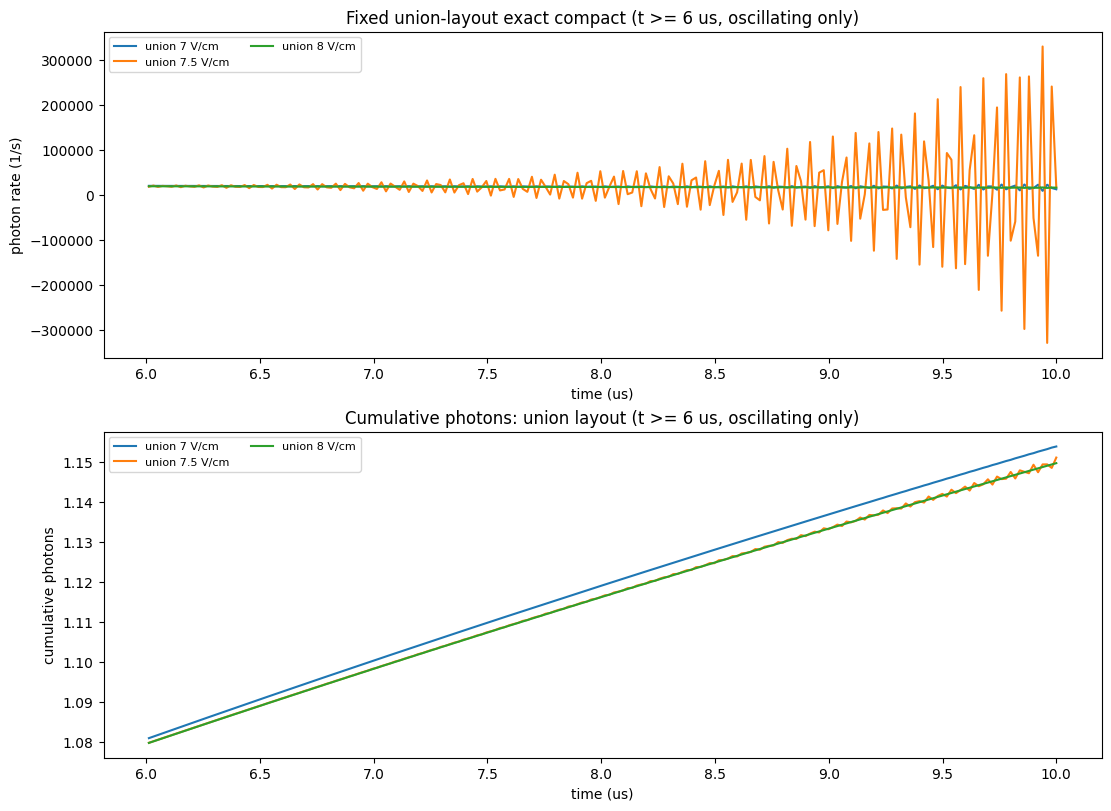

In [23]:
mask = T_EVAL >= 6e-6

not_flat_fields = [7, 7.5, 8]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

for field_vcm in not_flat_fields:
    axes[0].plot(
        1e6 * T_EVAL[mask],
        union_spot_rates[float(field_vcm)][mask],
        lw=1.5,
        label=f"union {field_vcm:g} V/cm",
    )
axes[0].set_xlabel("time (us)")
axes[0].set_ylabel("photon rate (1/s)")
axes[0].set_title("Fixed union-layout exact compact (t >= 6 us, oscillating only)")
axes[0].legend(ncol=2, fontsize=8)

for field_vcm in not_flat_fields:
    axes[1].plot(
        1e6 * T_EVAL[mask],
        union_spot_cumulative[float(field_vcm)][mask],
        lw=1.5,
        label=f"union {field_vcm:g} V/cm",
    )
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("cumulative photons")
axes[1].set_title("Cumulative photons: union layout (t >= 6 us, oscillating only)")
axes[1].legend(ncol=2, fontsize=8)

plt.show()
